In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Đọc dữ liệu từ file csv
df = pd.read_csv("kmeans2.csv")

df.head()

,x1,x2
0,1,5
1,3,5
2,2,14
3,3,4
4,12,4


In [3]:
# Hàm tính khoảng cách giữa tâm cụm và điểm dữ liệu
def Euclidean(x,y,centroid) -> float:
    # x: tọa độ của phần tử ith trên trục hoành
    # y: tọa độ của phần tử ith trên trục tung
    # a: tọa độ của cụm trên trục hoành
    # b: tọa độ của cụm trên trục tung
    a, b = centroid
    return np.sqrt(
            (x - a)**2 + (y - b)**2
            )

In [4]:
# --- Hàm phụ để vẽ đồ thị trực quan ---
def plot_step(D, clusters, centroids, step):
    plt.figure(figsize=(8, 6))
    
    # Định nghĩa danh sách các màu cho từng cụm (hỗ trợ tới 7 cụm)
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']
    
    # 1. Vẽ các điểm dữ liệu
    for i, cluster in enumerate(clusters):
        color = colors[i % len(colors)]
        if len(cluster) > 0:
            # Lấy tọa độ x1, x2 của các điểm trong cụm
            cluster_points = D.iloc[cluster]
            plt.scatter(cluster_points.iloc[:, 0], cluster_points.iloc[:, 1], 
                        c=color, label=f'Cụm {i}', alpha=0.6, s=50)
            
    # 2. Vẽ các tâm cụm (Đánh dấu X lớn)
    for i, centroid in enumerate(centroids):
        color = colors[i % len(colors)]
        plt.scatter(centroid[0], centroid[1], c=color, marker='X', s=250, edgecolors='black', linewidths=2)
        
    plt.title(f"Trực quan hóa K-Means - Tính lần {step}")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show() # Hiển thị đồ thị

Tọa độ tâm cụm 0 [6, 5]
Tọa độ tâm cụm 1 [4, 7]
Tọa độ tâm cụm 2 [1, 5]
--------------------------------------------------
Tính lần 1
Tính khoảng cách các điểm đến các tâm
           0         1          2
0   5.000000  3.605551   0.000000
1   3.000000  2.236068   2.000000
2   9.848858  7.280110   9.055385
3   3.162278  3.162278   2.236068
4   6.082763  8.544004  11.045361
5   4.123106  2.236068   1.414214
6   4.472136  6.000000   5.000000
7   9.219544  7.000000   9.486833
8   2.828427  0.000000   3.605551
9   2.236068  1.000000   3.162278
10  4.123106  6.708204   7.211103
11  0.000000  2.828427   5.000000
12  4.472136  7.211103   8.062258
13  3.605551  1.000000   4.242641
14  2.828427  5.656854   7.280110
15  1.000000  2.236068   4.000000
16  7.615773  5.099020   7.280110
17  8.062258  6.708204  10.000000
Cụm 0: [4, 6, 10, 11, 12, 14, 15]
Cụm 1: [2, 7, 8, 9, 13, 16, 17]
Cụm 2: [0, 1, 3, 5]
Cập nhật tâm cụm
Tọa độ tâm cụm 0 [7.142857142857143, 2.857142857142857]
Tọa độ tâm cụm 1 [4.0, 

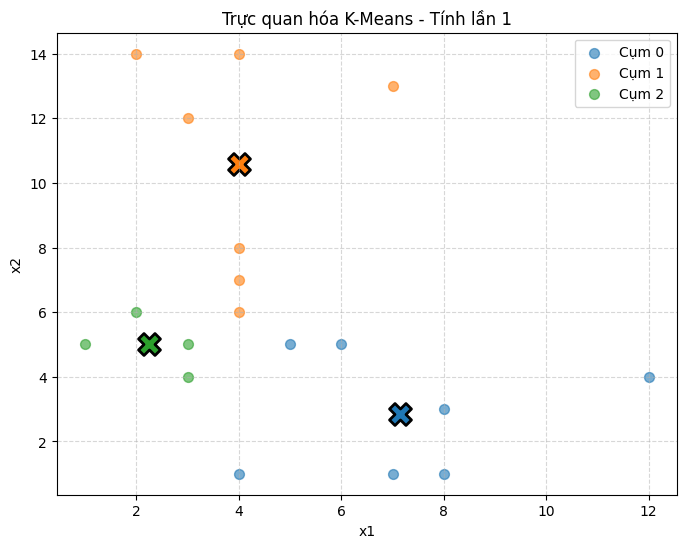

--------------------------------------------------
Tính lần 2
Tính khoảng cách các điểm đến các tâm
            0          1         2
0    6.505884   6.327781  1.250000
1    4.664236   5.660461  0.750000
2   12.272418   3.969270  9.003472
3    4.297603   6.647080  1.250000
4    4.989785  10.352955  9.801148
5    6.027149   4.989785  1.030776
6    3.650552   9.571429  4.366062
7   11.577600   3.428571  9.168560
8    5.200078   3.571429  2.657536
9    4.444671   4.571429  2.015564
10   1.862629  10.030566  6.209871
11   2.428571   5.919528  3.750000
12   2.045403  10.373632  7.004463
13   6.027149   2.571429  3.473111
14   0.868966   8.563091  6.087898
15   3.030458   5.660461  2.750000
16  10.037684   1.743794  7.040064
17  10.143863   3.859787  9.303897
Cụm 0: [4, 6, 10, 11, 12, 14]
Cụm 1: [2, 7, 13, 16, 17]
Cụm 2: [0, 1, 3, 5, 8, 9, 15]
Cập nhật tâm cụm
Tọa độ tâm cụm 0 [7.5, 2.5]
Tọa độ tâm cụm 1 [4.0, 12.2]
Tọa độ tâm cụm 2 [3.142857142857143, 5.428571428571429]


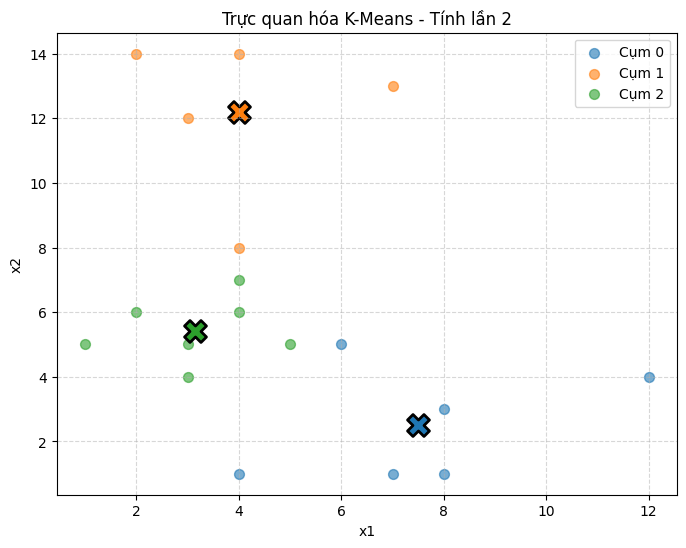

--------------------------------------------------
Tính lần 3
Tính khoảng cách các điểm đến các tâm
            0          1         2
0    6.964194   7.800000  2.185294
1    5.147815   7.269113  0.451754
2   12.747549   2.690725  8.647283
3    4.743416   8.260751  1.435697
4    4.743416  11.456003  8.971611
5    6.519202   6.514599  1.277753
6    3.807887  11.200000  4.510758
7   12.020815   1.800000  8.614179
8    5.700877   5.200000  1.789995
9    4.949747   6.200000  1.030158
10   1.581139  11.594826  5.872801
11   2.915476   7.472617  2.889107
12   1.581139  11.892855  6.572981
13   6.519202   4.200000  2.710524
14   0.707107  10.031949  5.430451
15   3.535534   7.269113  1.905952
16  10.511898   1.019804  6.572981
17  10.511898   3.104835  8.497298
Cụm 0: [4, 6, 10, 12, 14]
Cụm 1: [2, 7, 16, 17]
Cụm 2: [0, 1, 3, 5, 8, 9, 11, 13, 15]
Cập nhật tâm cụm
Tọa độ tâm cụm 0 [7.8, 2.0]
Tọa độ tâm cụm 1 [4.0, 13.25]
Tọa độ tâm cụm 2 [3.5555555555555554, 5.666666666666667]


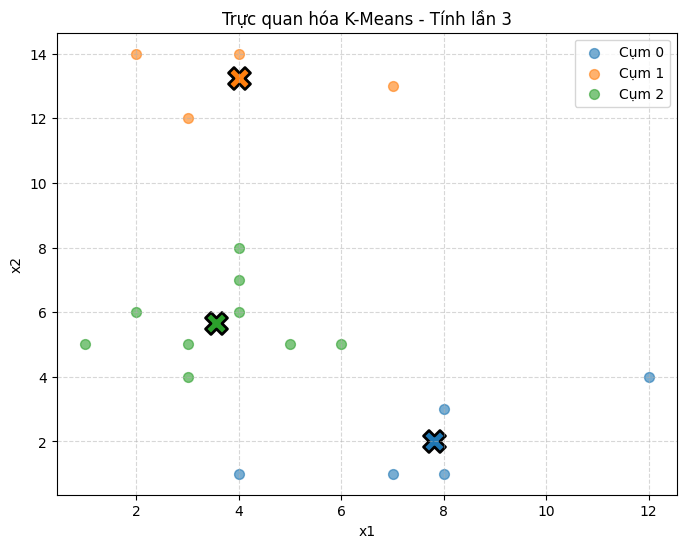

--------------------------------------------------
Tính lần 4
Tính khoảng cách các điểm đến các tâm
            0          1         2
0    7.432362   8.778525  2.641081
1    5.660389   8.310385  0.867806
2   13.328166   2.136001  8.477275
3    5.200000   9.303897  1.756821
4    4.651881  12.229575  8.607347
5    7.045566   7.520804  1.590869
6    3.929377  12.250000  4.687783
7   12.587295   0.750000  8.345177
8    6.280127   6.250000  1.405457
9    5.517246   7.250000  0.555556
10   1.280625  12.611998  5.800170
11   3.498571   8.488963  2.533723
12   1.019804  12.886524  6.444444
13   7.102112   5.250000  2.375284
14   1.019804  11.002841  5.183068
15   4.103657   8.310385  1.590869
16  11.092340   1.600781  6.357653
17  11.029053   3.010399  8.101974
Cụm 0: [4, 6, 10, 12, 14]
Cụm 1: [2, 7, 16, 17]
Cụm 2: [0, 1, 3, 5, 8, 9, 11, 13, 15]
Cập nhật tâm cụm
Tọa độ tâm cụm 0 [7.8, 2.0]
Tọa độ tâm cụm 1 [4.0, 13.25]
Tọa độ tâm cụm 2 [3.5555555555555554, 5.666666666666667]


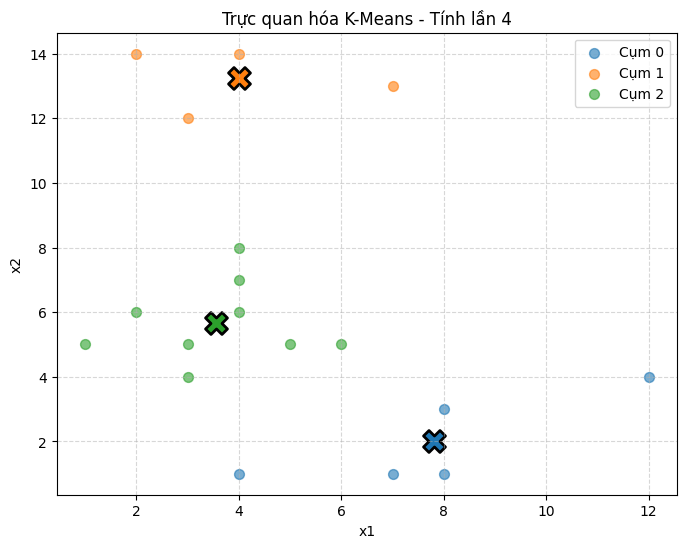

--------------------------------------------------
Số cụm hội tụ, thuật toán dừng lại


In [5]:
def Kmeans(D: pd.DataFrame, k: int) -> str:
    # Khởi tạo cụm rỗng
    clusters = None
    new_clusters = [[] for _ in range(k)]

    # Khởi tạo ngẫu nhiên k điểm làm tâm cụm
    tam_indicies = np.random.choice(len(D), size=k, replace=False).tolist()
    centroids = [D.iloc[idx] for idx in tam_indicies]
    for i, centroid in enumerate(centroids):
        print(f"Tọa độ tâm cụm {i}", centroid.tolist())
    
    # Khởi tạo ma trận để tính khoảng cách
    matrix = np.zeros((len(D), k))
    D_matrix = pd.DataFrame(matrix)
    
    # Lấy kích thước ma trận
    rows = D_matrix.shape[0]
    cols = D_matrix.shape[1]
    
    print("--------------------------------------------------")

    step = 1
    
    while(clusters != new_clusters):
        print(f"Tính lần {step}")
        clusters = [list(c) for c in new_clusters]        
        # Tính khoảng cách các điểm đến tâm cụm rồi gán vào ma trận
        for j in range(cols):
            centroid = centroids[j]
            for i in range(rows):
                x, y = D.iloc[i]
                D_matrix.iloc[i, j] = Euclidean(x, y, centroid)
        
        # Tìm ra phần tử có khoảng cách nhỏ nhất so với các tâm cụm
        print("Tính khoảng cách các điểm đến các tâm")
        temp_cluster = [[] for _ in range(k)]
        for i in range(rows):
            min_dist = float('inf') # Giá trị dương rất lớn
            idx = 0
            for j in range(cols):
                if min_dist > D_matrix.iloc[i,j]:
                    min_dist = D_matrix.iloc[i, j]
                    idx = j
            temp_cluster[idx].append(i)
        new_clusters = temp_cluster
        print(D_matrix)
        for i, cluster in enumerate(new_clusters):
            print(f"Cụm {i}:", cluster)
        
        print("Cập nhật tâm cụm")
        new_centroids = []
        for cluster in new_clusters:
            D_cluster = D.iloc[cluster]
            new_centroid = D_cluster.mean().tolist()
            new_centroids.append(new_centroid)
        centroids = new_centroids
        for i, centroid in enumerate(centroids):
            print(f"Tọa độ tâm cụm {i}", centroid)
        
        plot_step(D, new_clusters, centroids, step)
        
        step += 1
        print("--------------------------------------------------")
    return "Số cụm hội tụ, thuật toán dừng lại"

print(Kmeans(df, 3))